# $\Omega_{GW}(f)$ Signature with the Transfer Function Applied

This document will take models from a NEQs=8 run and generate gravitational wave signatures from them. First we need to identify what transfer function we are using. This one that we are going to use come from Satorishi. We should take care to make sure we can identify what each bump corresponds to.

First, let's import necessary packages:

In [2]:

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.ticker import ScalarFormatter


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



## Models from NEQs=8

The plot below does not account for any Nshift difference yet, it is just a sum of all models within the spectral range of interest.

In [7]:
def plot_filtered_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(value):
        val_str = f"{value:.10e}"
        f = os.path.join(folder_for(value), f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(f, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping N range between model and base.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)
        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    base_data = load_path(baseX)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base, H_base, N_ref)
    N_base_eps, eps_base_norm, eps_ref = normalize_at_ref(N_base, eps_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path(lamX)

            H = data[:, 1]
            eps = data[:, 2]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N, eps, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_error_on_base_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_eps, frac_eps = fractional_error_on_base_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

            N_frac_V, frac_V = fractional_error_on_base_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            kept_models.append({
                **row,

                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_eps": N_eps_plot,
                "eps_N": eps_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,

                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_eps": N_frac_eps,
                "frac_eps": frac_eps,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,

                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_deps_pct": 100.0 * np.nanmean(frac_eps),
                "max_deps_pct": 100.0 * np.nanmax(np.abs(frac_eps)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N",
                "N_eps", "eps_N",
                "N_V", "V_N",
                "N_frac_H", "frac_H",
                "N_frac_eps", "frac_eps",
                "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== Background models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_models)}")

    if len(kept_models) > 0:
        print("\n=== Background fractional errors in percent ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "mean_dH_pct",
                "max_dH_pct",
                "mean_deps_pct",
                "max_deps_pct",
                "mean_dV_pct",
                "max_dV_pct",
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]
    ax_epsN, ax_epserr = axes[2]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)
            ax_epsN.plot(m["N_eps"], m["eps_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_epserr.plot(
                m["N_frac_eps"],
                100.0 * m["frac_eps"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_epsN.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_Herr, ax_Verr, ax_epserr]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
    ax_epsN.set_title(rf"Filtered normalized slow-roll evolution: $\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Fractional difference in normalized potential evolution")
    ax_epserr.set_title(r"Fractional difference in normalized $\epsilon(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_epserr.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_epserr.set_ylim(eps_frac_ylim)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors_with_epsilon.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df


Summary for NEQS=8, parameter=lam5
Total models found: 30
Parameter range: -4.368e-05 to 4.798e-05


=== Background models summary ===
Total loaded: 30
Base ns: 0.969485
Models in ns window [0.96, 0.971]: 30

=== Background fractional errors in percent ===
         lamX       ns  mean_dH_pct  max_dH_pct  mean_deps_pct  max_deps_pct  mean_dV_pct  max_dV_pct
-4.368160e-05 0.963749     0.522039    1.448343     -79.357000     99.722924     1.065809    2.956590
-4.299231e-05 0.965168     0.338329    1.132197     -55.907917     98.164601     0.691944    2.313650
-3.749540e-05 0.962371     0.306419    1.114828     -59.887954     98.817426     0.629069    2.279717
-3.670782e-05 0.965415     0.398336    1.268665     -70.309878     99.269031     0.815719    2.592031
-3.548306e-05 0.964969     0.265262    1.076069     -61.331699     99.193170     0.547126    2.202276
-3.430502e-05 0.965781     0.729515    1.702408      67.597455    197.563102     1.478480    3.465571
-3.243509e-05 0.968167     0

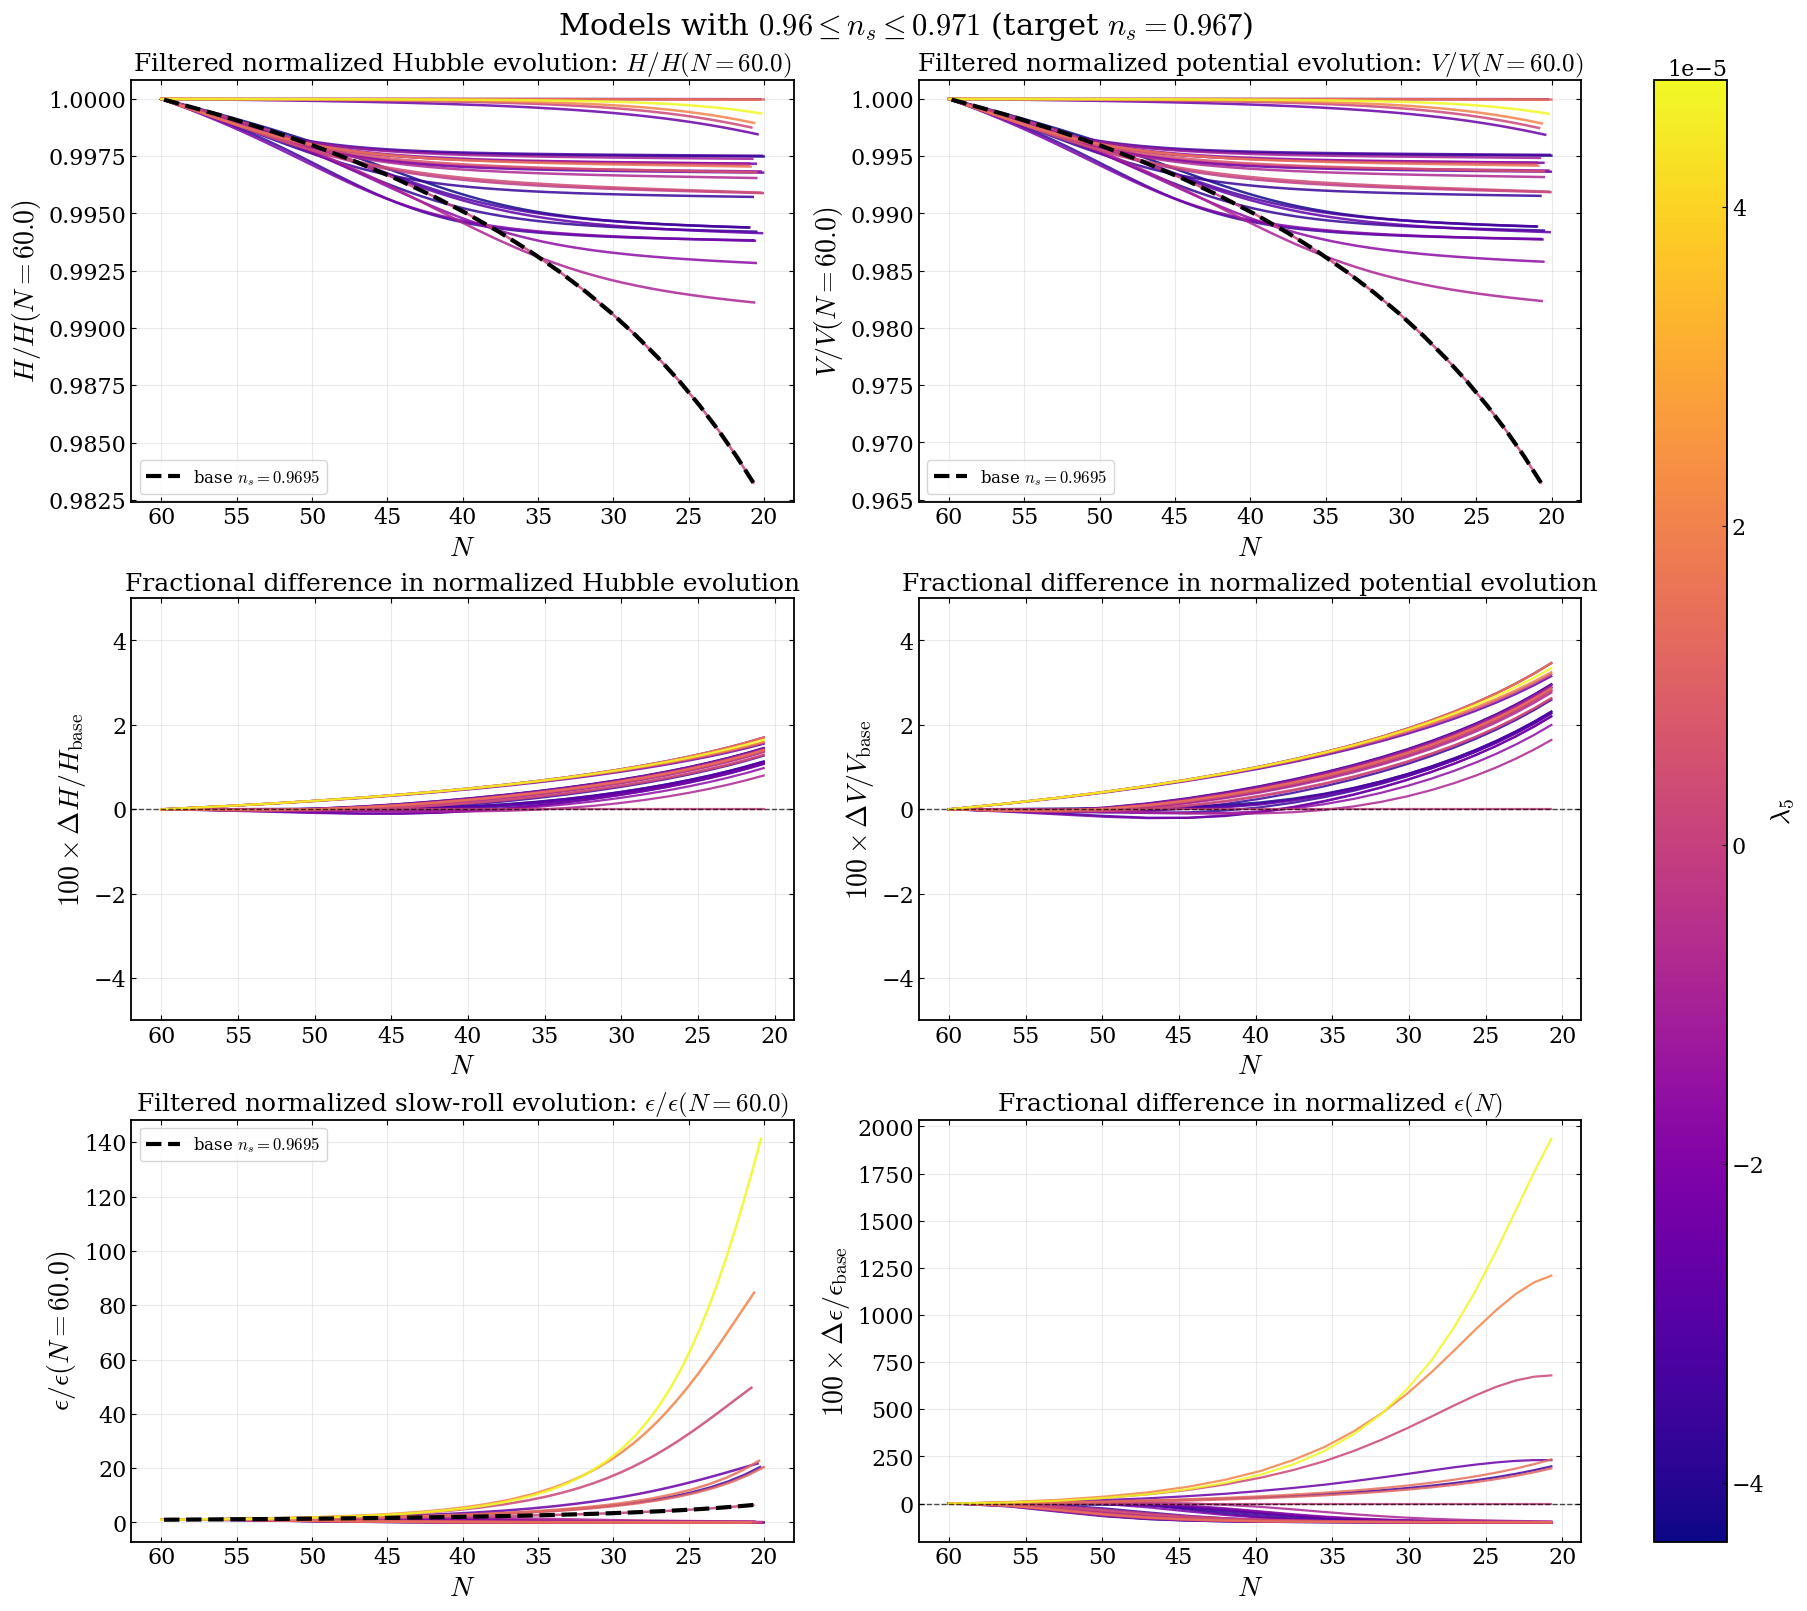

In [12]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}


LAM_BASE = {
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10), #we can test 9 later if we really want to 
}


base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"

def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

    print(f"NEQS={NEQS}: {folder}")


lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)


bg8_df = plot_filtered_background_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs8_lam5_background_3higherorder_random.png",
)

## Power Spectra for Set of Models


In [15]:
## Other Functions to include

def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]


Before applying an N-shift:

In [18]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    
    
    plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,

    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    })

        
        
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_observables(value):
        arr = np.loadtxt(
            os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat")
        )
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "delta_ns_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check in percentages ===")
        print("All models:")
        print(
            stats_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

        print("\nFiltered models:")
        print(
            kept_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = scalar_k_mask(m["k_s"])

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"{ns_min}_{ns_max}_kmin{k_min_scalar}_kmax{k_max_scalar}.png"
        )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Total loaded: 30
Base ns: 0.969485
Models in ns window [0.96, 0.971]: 30

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
 2.055446e-05 0.960474           -0.009012      5.657910    10.437436      1.029580     3.735363
-2.159077e-05 0.961350           -0.008136      3.253971     6.756279      0.528412     3.046322
-2.570681e-05 0.962248           -0.007237      3.195280     6.352609      0.995112     3.646317
-3.749540e-05 0.962371           -0.007115      0.842692     2.858260      0.554542     3.075197
-8.628656e-06 0.962812           -0.006673      0.683116     2.444837      0.316371     2.396337
-4.368160e-05 0.963749           -0.005737     -8.518946    12.175035      0.929433     3.767642
-1.702759e-05 0.963908           -0.005578      0.816558     2.400135      0.439198     2.781305
 1.553792e-06 0.963949           -0.005536      4.492161     7.888301      1.015230     

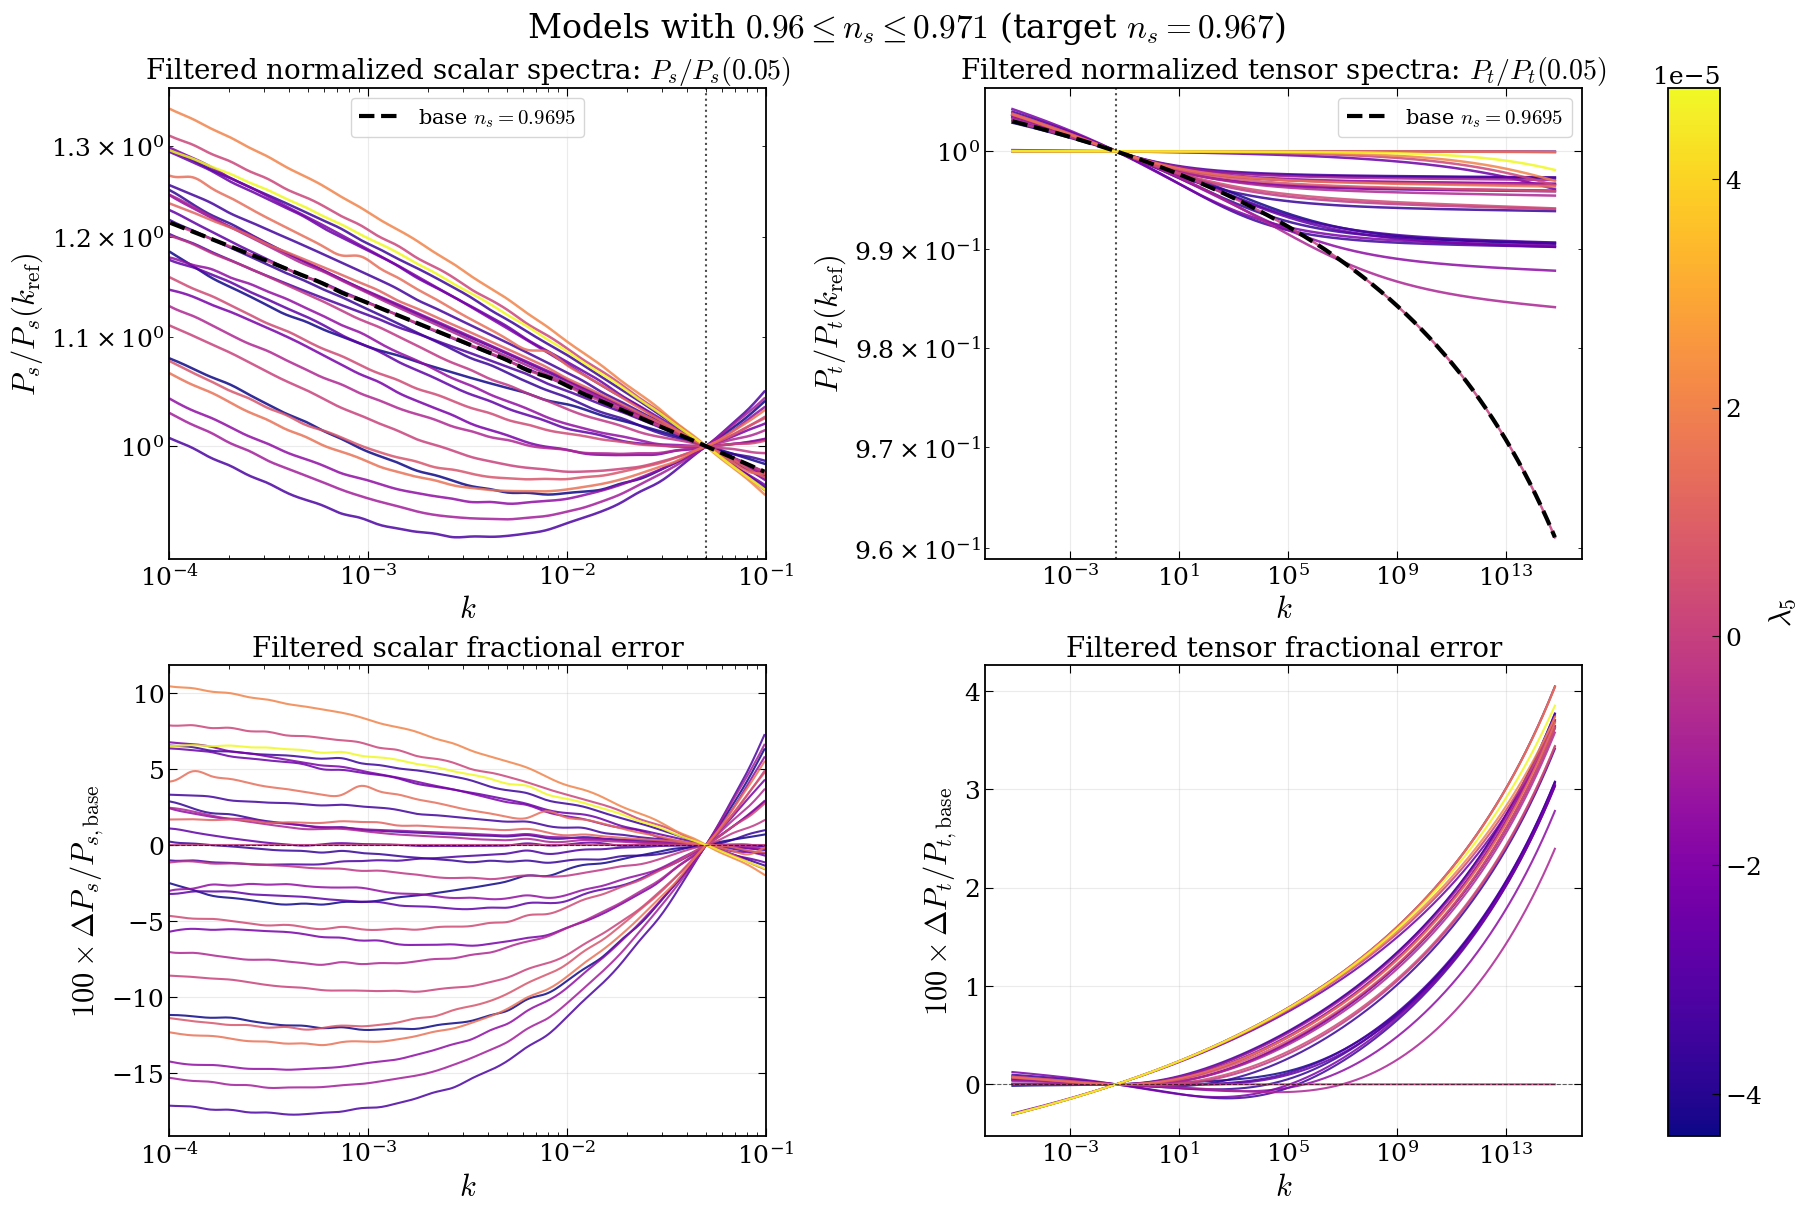

In [19]:

stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -8.92461e-9,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs8_lam5_filtered_ns_spectra.png"
)


After applying an N_shift:

In [16]:
def plot_k_shift_equivalence_scan_2x2(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,

    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,

    cmap_name="plasma",
    save_name=None,
):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman",
            "Times New Roman",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",

        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,

        "xtick.labelsize": 13,
        "ytick.labelsize": 13,

        "legend.fontsize": 11,

        "axes.linewidth": 1.2,

        "xtick.direction": "in",
        "ytick.direction": "in",

        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 6,
        "ytick.major.size": 6,

        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(
            os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        )

        t = np.loadtxt(
            os.path.join(folder, f"spec_t_neqs{NEQS}.dat")
        )

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref, P_ref

    def frac_on_base_grid(
        k_base,
        P_base,
        k_cmp,
        P_cmp,
        kmin=None,
        kmax=None,
    ):
        k_base, P_base = prepare_increasing(k_base, P_base)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_base.min(), k_cmp.min())
        xmax = min(k_base.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_base >= xmin) & (k_base <= xmax)

        k_use = k_base[mask]
        P_base_use = P_base[mask]

        if len(k_use) == 0:
            raise ValueError(
                f"No overlapping k range after cuts: "
                f"kmin={kmin}, kmax={kmax}"
            )

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_base_use) / P_base_use

        return k_use, frac

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    lam_vals = sanitize_lam_values(lamX_values)

    base_N_end = get_original_N_end(baseX)

    (
        k_s_base_raw,
        Ps_base_raw,
        k_t_base_raw,
        Pt_base_raw,
    ) = load_specs_local(baseX)

    k_s_base, Ps_base_norm, _ = normalize_at_k(
        k_s_base_raw,
        Ps_base_raw,
        k_norm,
    )

    k_t_base, Pt_base_norm, _ = normalize_at_k(
        k_t_base_raw,
        Pt_base_raw,
        k_norm,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.min(lam_vals),
        vmax=np.max(lam_vals),
    )

    rows = []

    for value in lam_vals:
        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end

            (
                k_s_raw,
                Ps_raw,
                k_t_raw,
                Pt_raw,
            ) = load_specs_local(value)

            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s, Ps_norm, _ = normalize_at_k(
                k_s_shifted,
                Ps_raw,
                k_norm,
            )

            k_t, Pt_norm, _ = normalize_at_k(
                k_t_shifted,
                Pt_raw,
                k_norm,
            )

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmin=k_min_scalar,
                kmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmin=None,
                kmax=None,
            )

            color = cmap(norm(value))

            mask_s = scalar_k_mask(k_s)

            ax_ps.loglog(
                k_s[mask_s],
                Ps_norm[mask_s],
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_pt.loglog(
                k_t,
                Pt_norm,
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_ps_err.semilogx(
                k_ps_err,
                100.0 * frac_ps,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            ax_pt_err.semilogx(
                k_pt_err,
                100.0 * frac_pt,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "exp_minus_deltaN": np.exp(-deltaN),
                "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except FileNotFoundError:
            print(
                f"Missing files for {scan_name}={value:.5e}"
            )

        except ValueError as e:
            print(
                f"Skipping {scan_name}={value:.5e}: {e}"
            )

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_pt.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")

    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    ax_pt.set_xlim(k_t_base.min(), k_t_base.max())
    ax_pt_err.set_xlim(k_t_base.min(), k_t_base.max())

    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    for ax in axes.ravel():
        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.025,
        fraction=0.035,
    )

    cbar.set_label(
        rf"${scan_symbol}$",
        fontsize=16,
    )

    cbar.ax.tick_params(
        labelsize=12,
        direction="in",
    )

    fig.suptitle(
        rf"NEQS={NEQS}: spectra shifted relative to the reference model",
        y=1.02,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_"
            f"{scan_name}_"
            f"kshifted_spectra_"
            f"kmin{k_min_scalar}_"
            f"kmax{k_max_scalar}.png"
        )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print(
            "\n=== Shifted spectra fractional-error summary ==="
        )

        print(
            stats_df[[
                scan_name,
                "deltaN_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

Skipping lam5=-3.43050e-05: k_ref=0.05 outside shifted k range [3.072e+69, 2.551e+89]
Skipping lam5=-2.57068e-05: k_ref=0.05 outside shifted k range [1.579e-23, 1.311e-03]
Skipping lam5=-2.15908e-05: k_ref=0.05 outside shifted k range [1.241e-01, 1.031e+19]
Skipping lam5=1.55379e-06: k_ref=0.05 outside shifted k range [3.442e-23, 2.858e-03]
Skipping lam5=1.12808e-05: k_ref=0.05 outside shifted k range [1.202e+60, 9.983e+79]
Skipping lam5=1.41617e-05: k_ref=0.05 outside shifted k range [1.327e+66, 1.102e+86]
Skipping lam5=2.05545e-05: k_ref=0.05 outside shifted k range [3.142e-23, 2.609e-03]
Skipping lam5=4.79803e-05: k_ref=0.05 outside shifted k range [5.858e-24, 4.864e-04]


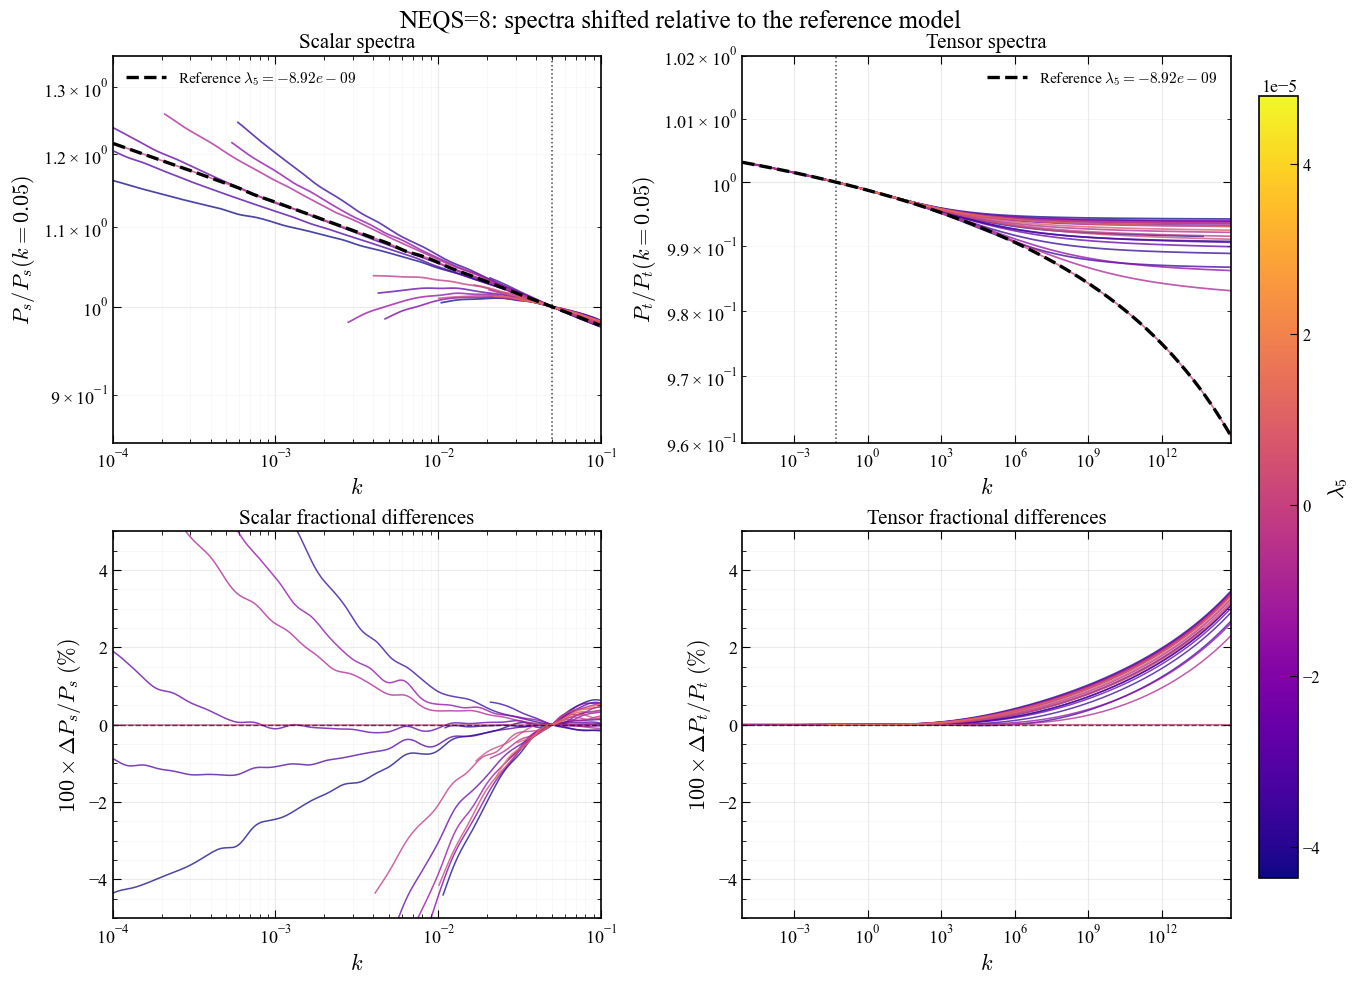


=== Shifted spectra fractional-error summary ===
         lam5  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.368160e-05         -7.202026     -1.085599     4.400947      0.874715     3.451071
-4.299231e-05          2.591112     -1.691402     4.348857      0.478795     2.482182
-3.749540e-05         -4.325251      2.156657     8.073369      0.545534     2.894119
-3.670782e-05         -7.248876     -0.018497     0.079972      0.683366     3.088784
-3.548306e-05         -7.888590      0.133201     0.581433      0.483428     2.672007
-3.243509e-05         -8.295805      0.090021     0.643637      0.876099     3.409795
-3.203578e-05         -0.160869     -0.684713     1.310086      0.576499     3.073155
-2.810717e-05         -6.311915     -1.782299     6.131420      0.798941     3.345703
-2.732926e-05         -0.787295      0.183921     1.888606      0.556900     3.002799
-2.195481e-05         -6.406384     -2.426427     8.732715      0.841123     3.420721
-1.7

In [17]:
shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    frac_ylim=(-5, 5),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    cmap_name="plasma",
    save_name="neqs8_lam5_shifted_spectra_2x2.png",
)



## Transfer Function to be Applied

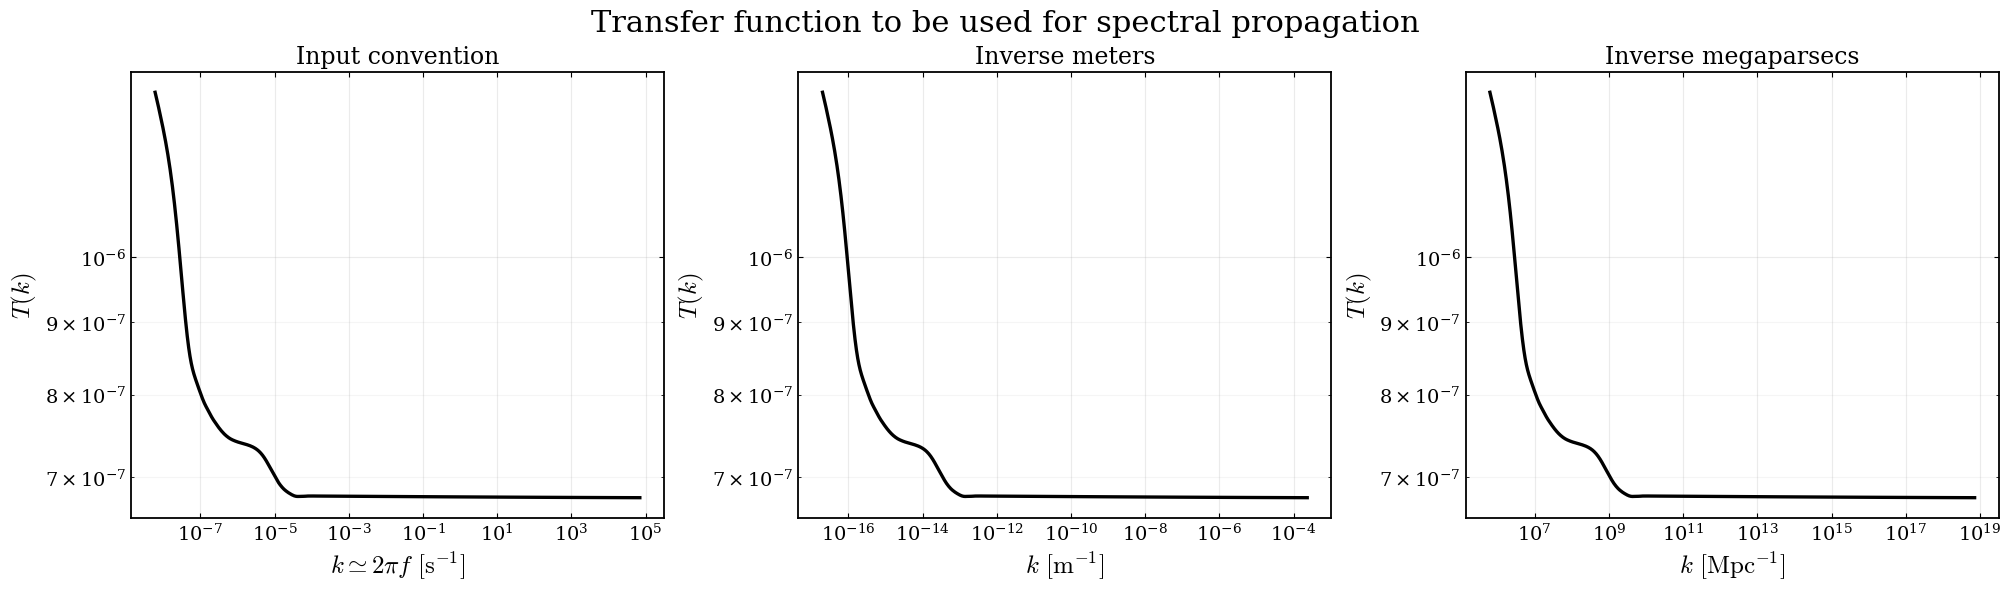

k from data for tf:
6e-09 69740.4

f from data for tf:
9.5493e-10 11099.5

TF median from data:
6.77425e-07 1.3063e-06

k after converting to inverse Mpc:
617562.9710460028 7.178159862110426e+18

ratio of k/(2*pi*f):
0.9999927220232102 1.0000068685629133


In [6]:
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

base_path_tf = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests"
)

tf_k = np.loadtxt(base_path_tf / "k_file_tf.dat")
tf_f = np.loadtxt(base_path_tf / "f_file_tf.dat")
tf_median = np.loadtxt(base_path_tf / "Tf_median.dat")

tf_k_invm = tf_f * 2.0 * np.pi / 299792458.0
tf_k_invMpc = tf_k_invm * 3.085677581e22

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.8),
    constrained_layout=True,
)

plot_data = [
    (
        tf_k,
        tf_median,
        r"$k \simeq 2\pi f\ [{\rm s}^{-1}]$",
        r"$T(k)$",
        r"Input convention",
    ),
    (
        tf_k_invm,
        tf_median,
        r"$k\ [{\rm m}^{-1}]$",
        r"$T(k)$",
        r"Inverse meters",
    ),
    (
        tf_k_invMpc,
        tf_median,
        r"$k\ [{\rm Mpc}^{-1}]$",
        r"$T(k)$",
        r"Inverse megaparsecs",
    ),
]

for ax, (x, y, xlabel, ylabel, title) in zip(axes, plot_data):
    ax.loglog(
        x,
        y,
        color="black",
        lw=2.4,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()

fig.suptitle(r"Transfer function to be used for spectral propagation", fontsize=22)

plt.savefig(
    "transfer_function_conventions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("k from data for tf:")
print(tf_k.min(), tf_k.max())

print("\nf from data for tf:")
print(tf_f.min(), tf_f.max())

print("\nTF median from data:")
print(tf_median.min(), tf_median.max())

print("\nk after converting to inverse Mpc:")
print(tf_k_invMpc.min(), tf_k_invMpc.max())

ratio = tf_k / (2.0 * np.pi * tf_f)

print("\nratio of k/(2*pi*f):")
print(np.nanmin(ratio), np.nanmax(ratio))

## $\Omega_{GW}$ for all models in spectral range with shift applied

In [22]:
def plot_shifted_omegaGW_scan(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    h=0.67,
    k_norm=0.05,
    k0=1.6e14,
    max_abs_deltaN=None,
    cmap_name="plasma",
    alpha=0.65,
    lw=1.6,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[scan_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    # -------------------------------------------------
    # Transfer function interpolation
    # -------------------------------------------------
    tf_k = np.asarray(tf_k_invMpc)
    tf_T = np.asarray(tf_median)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    order_tf = np.argsort(tf_k)
    tf_k = tf_k[order_tf]
    tf_T = tf_T[order_tf]

    logT_spline = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k.min()
    kmax_tf = tf_k.max()

    lam_vals = sanitize_lam_values(lamX_values)
    base_N_end = get_original_N_end(baseX)

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
    )

    ax_h2, ax_plain = axes

    rows = []

    n_total = 0
    n_kept = 0
    n_rejected_deltaN = 0
    n_rejected_overlap = 0
    n_rejected_other = 0

    for value in lam_vals:
        n_total += 1

        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end
            abs_deltaN = np.abs(deltaN)

            if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                n_rejected_deltaN += 1
                continue

            _, _, k_t_raw, Pt_raw = load_specs_local(value)

            # Shift tensor spectrum before applying transfer function.
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            mask = (
                np.isfinite(k_t_shifted)
                & np.isfinite(Pt_raw)
                & (k_t_shifted > 0)
                & (Pt_raw > 0)
                & (k_t_shifted >= kmin_tf)
                & (k_t_shifted <= kmax_tf)
            )

            if np.count_nonzero(mask) < 5:
                n_rejected_overlap += 1
                print(
                    f"[skip] {scan_name}={value:.5e}: "
                    "insufficient overlap with transfer-function range"
                )
                continue

            k_use = k_t_shifted[mask]
            Pt_use = np.abs(Pt_raw[mask])

            logT = logT_spline(np.log(k_use))
            T_use = np.exp(logT)

            valid = np.isfinite(T_use) & (T_use > 0)

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]

            if len(k_use) < 5:
                n_rejected_overlap += 1
                continue

            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / (h**2)

            color = cmap(norm(value))

            ax_h2.loglog(
                k_use,
                OmegaGW_h2,
                color=color,
                lw=lw,
                alpha=alpha,
            )

            ax_plain.loglog(
                k_use,
                OmegaGW,
                color=color,
                lw=lw,
                alpha=alpha,
            )

            j0 = np.argmin(np.abs(k_use - k0))

            ax_h2.scatter(
                k_use[j0],
                OmegaGW_h2[j0],
                s=22,
                color="crimson",
                alpha=0.45,
                zorder=5,
            )

            ax_plain.scatter(
                k_use[j0],
                OmegaGW[j0],
                s=22,
                color="crimson",
                alpha=0.45,
                zorder=5,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "abs_deltaN_from_base": abs_deltaN,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "k_nearest_k0": k_use[j0],
                "OmegaGW_h2_at_k0": OmegaGW_h2[j0],
                "OmegaGW_at_k0": OmegaGW[j0],
                "OmegaGW_h2_min": np.nanmin(OmegaGW_h2),
                "OmegaGW_h2_max": np.nanmax(OmegaGW_h2),
                "OmegaGW_min": np.nanmin(OmegaGW),
                "OmegaGW_max": np.nanmax(OmegaGW),
            })

            n_kept += 1

        except FileNotFoundError:
            n_rejected_other += 1
            print(f"Missing files for {scan_name}={value:.5e}")

        except ValueError as e:
            n_rejected_other += 1
            print(f"Skipping {scan_name}={value:.5e}: {e}")

    for ax in axes:
        ax.axvline(
            k0,
            color="crimson",
            linestyle="--",
            lw=2.0,
            alpha=0.85,
            label=rf"$k_0=1.6\times10^{{14}}\,{{\rm Mpc}}^{{-1}}$",
        )

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()
        ax.legend(frameon=False, loc="best")

    ax_h2.set_title(r"Shifted tensor spectra after transfer function")
    ax_plain.set_title(r"Shifted tensor spectra after transfer function")

    ax_h2.set_xlabel(r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$")
    ax_plain.set_xlabel(r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$")

    ax_h2.set_ylabel(r"$\Omega_{\rm GW}h^2(k)$")
    ax_plain.set_ylabel(r"$\Omega_{\rm GW}(k)$")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.035)
    cbar.set_label(rf"${scan_symbol}$", fontsize=18)
    cbar.ax.tick_params(labelsize=14, direction="in")

    cut_text = ""
    if max_abs_deltaN is not None:
        cut_text = rf", $|\Delta N|\leq {max_abs_deltaN}$"

    fig.suptitle(
        rf"NEQS={NEQS}: transferred $\Omega_{{\rm GW}}$ from shifted tensor spectra{cut_text}",
        fontsize=22,
    )

    if save_name is None:
        if max_abs_deltaN is None:
            save_name = f"neqs{NEQS}_{scan_name}_shifted_omegaGW_scan.png"
        else:
            save_name = (
                f"neqs{NEQS}_{scan_name}_shifted_omegaGW_"
                f"dN{max_abs_deltaN}.png"
            )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    omega_df = pd.DataFrame(rows)

    print("\n=== Shifted OmegaGW filtering summary ===")
    print(f"Total models checked      : {n_total}")
    print(f"Kept models               : {n_kept}")
    print(f"Rejected by |deltaN| cut  : {n_rejected_deltaN}")
    print(f"Rejected by TF overlap    : {n_rejected_overlap}")
    print(f"Rejected other            : {n_rejected_other}")

    if max_abs_deltaN is not None:
        print(f"Cut applied: |deltaN| <= {max_abs_deltaN}")

    print("\n=== Shifted OmegaGW summary ===")
    if not omega_df.empty:
        print(
            omega_df[[
                scan_name,
                "deltaN_from_base",
                "abs_deltaN_from_base",
                "k_nearest_k0",
                "OmegaGW_h2_at_k0",
                "OmegaGW_at_k0",
            ]].to_string(index=False)
        )

    return omega_df

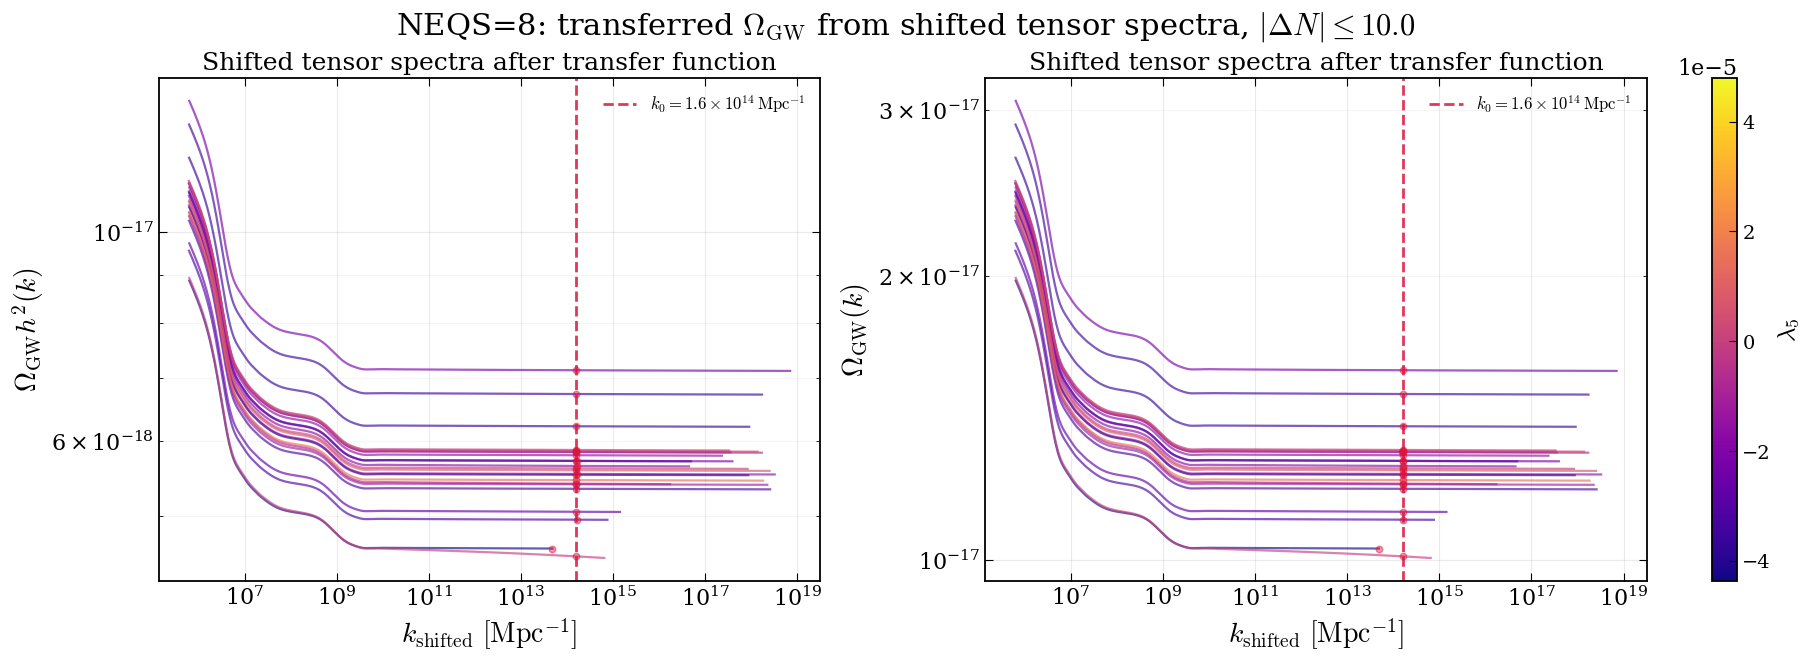


=== Shifted OmegaGW filtering summary ===
Total models checked      : 30
Kept models               : 23
Rejected by |deltaN| cut  : 7
Rejected by TF overlap    : 0
Rejected other            : 0
Cut applied: |deltaN| <= 10.0

=== Shifted OmegaGW summary ===
         lam5  deltaN_from_base  abs_deltaN_from_base  k_nearest_k0  OmegaGW_h2_at_k0  OmegaGW_at_k0
-4.368160e-05         -7.202026              7.202026  1.604794e+14      5.526688e-18   1.231162e-17
-4.299231e-05          2.591112              2.591112  4.848402e+13      4.615357e-18   1.028148e-17
-3.749540e-05         -4.325251              4.325251  1.617770e+14      5.716280e-18   1.273397e-17
-3.670782e-05         -7.248876              7.248876  1.586556e+14      6.221017e-18   1.385836e-17
-3.548306e-05         -7.888590              7.888590  1.584402e+14      6.730737e-18   1.499385e-17
-3.243509e-05         -8.295805              8.295805  1.583228e+14      5.339518e-18   1.189467e-17
-3.203578e-05         -0.160869    

In [23]:
omega8_df = plot_shifted_omegaGW_scan(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    h=0.67,
    k_norm=0.05,
    k0=1.6e14,
    max_abs_deltaN=10.0,
    cmap_name="plasma",
    save_name="neqs8_lam5_shifted_omegaGW_dN10.png",
)

## Consistent $\Omega_{GW}$ ($k_0 = 1.6 \times 10^{14}$) = $(8.2 \pm 0.69) \times 10^{-17}$

The original paper by Caliguiri et al identifies models that are consitent with this value of $\Omega_{GW}$ at $k_0 = 1.6 \times 10^{14}$ which roughly corresponds to a frequency of 0.25 Hz. We can also identify those models here AND we can look at a plot of the gravitational energy density curves with their $\Delta$$N$. 

In [28]:
def plot_shifted_omegaGW_pass_fail(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    h=0.67,
    k0=1.6e14,
    omega_target=8.2e-17,
    omega_tol=0.69e-17,
    max_abs_deltaN=None,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables_local(value):
        folder = folder_for(value)
        arr = np.atleast_1d(
            np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        )
        return arr[0], arr[1], arr[2]

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[scan_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    # Transfer function: log-log interpolation
    tf_k = np.asarray(tf_k_invMpc)
    tf_T = np.asarray(tf_median)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    order_tf = np.argsort(tf_k)
    tf_k = tf_k[order_tf]
    tf_T = tf_T[order_tf]

    logT_spline = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k.min()
    kmax_tf = tf_k.max()

    lam_vals = sanitize_lam_values(lamX_values)
    base_N_end = get_original_N_end(baseX)

    rows = []

    n_total = 0
    n_kept = 0
    n_pass = 0
    n_fail = 0
    n_rejected_deltaN = 0
    n_rejected_overlap = 0
    n_rejected_other = 0

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
    )

    ax_curves, ax_scatter = axes

    for value in lam_vals:
        n_total += 1

        try:
            r, ns, alpha_s = load_observables_local(value)

            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end
            abs_deltaN = np.abs(deltaN)

            if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                n_rejected_deltaN += 1
                continue

            _, _, k_t_raw, Pt_raw = load_specs_local(value)

            # Apply the same N-shift as the spectra diagnostic.
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            mask = (
                np.isfinite(k_t_shifted)
                & np.isfinite(Pt_raw)
                & (k_t_shifted > 0)
                & (Pt_raw > 0)
                & (k_t_shifted >= kmin_tf)
                & (k_t_shifted <= kmax_tf)
            )

            if np.count_nonzero(mask) < 5:
                n_rejected_overlap += 1
                continue

            k_use = k_t_shifted[mask]
            Pt_use = np.abs(Pt_raw[mask])

            logT = logT_spline(np.log(k_use))
            T_use = np.exp(logT)

            valid = np.isfinite(T_use) & (T_use > 0)

            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]

            if len(k_use) < 5:
                n_rejected_overlap += 1
                continue

            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / (h**2)

            j0 = np.argmin(np.abs(k_use - k0))

            k_near = k_use[j0]
            omega_h2_k0 = OmegaGW_h2[j0]
            omega_k0 = OmegaGW[j0]

            passes_omega = np.abs(omega_k0 - omega_target) <= omega_tol

            if passes_omega:
                curve_color = "royalblue"
                curve_alpha = 0.95
                curve_lw = 2.2
                zorder = 5
                n_pass += 1
            else:
                curve_color = "lightgray"
                curve_alpha = 0.55
                curve_lw = 1.3
                zorder = 2
                n_fail += 1

            ax_curves.loglog(
                k_use,
                OmegaGW,
                color=curve_color,
                alpha=curve_alpha,
                lw=curve_lw,
                zorder=zorder,
            )

            ax_curves.scatter(
                k_near,
                omega_k0,
                color="crimson" if passes_omega else "gray",
                s=28 if passes_omega else 18,
                alpha=0.8,
                zorder=zorder + 1,
            )

            ax_scatter.scatter(
                abs_deltaN,
                omega_k0,
                color="royalblue" if passes_omega else "lightgray",
                edgecolor="black" if passes_omega else "gray",
                linewidth=0.6 if passes_omega else 0.3,
                s=90 if passes_omega else 55,
                alpha=0.95 if passes_omega else 0.6,
                zorder=zorder,
            )

            rows.append({
                scan_name: value,
                "r": r,
                "n_s": ns,
                "alpha_s": alpha_s,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "abs_deltaN_from_base": abs_deltaN,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "k_nearest_k0": k_near,
                "OmegaGW_h2_at_k0": omega_h2_k0,
                "OmegaGW_at_k0": omega_k0,
                "Omega_target": omega_target,
                "Omega_tol": omega_tol,
                "passes_omega": passes_omega,
            })

            n_kept += 1

        except FileNotFoundError:
            n_rejected_other += 1
            print(f"Missing files for {scan_name}={value:.5e}")

        except ValueError as e:
            n_rejected_other += 1
            print(f"Skipping {scan_name}={value:.5e}: {e}")

    # Target markers
    omega_low = omega_target - omega_tol
    omega_high = omega_target + omega_tol

    for ax in axes:
        ax.axhspan(
            omega_low,
            omega_high,
            color="royalblue",
            alpha=0.12,
            label=rf"$\Omega_{{\rm GW}}(k_0)=(8.2\pm0.69)\times10^{{-17}}$",
        )

        ax.axhline(
            omega_target,
            color="royalblue",
            ls="--",
            lw=1.8,
            alpha=0.9,
        )

    ax_curves.axvline(
        k0,
        color="crimson",
        ls="--",
        lw=2.0,
        alpha=0.85,
        label=rf"$k_0=1.6\times10^{{14}}\,{{\rm Mpc}}^{{-1}}$",
    )

    ax_curves.set_xscale("log")
    ax_curves.set_yscale("log")
    ax_scatter.set_yscale("log")

    ax_curves.set_title(r"Transferred spectra from shifted tensor modes")
    ax_scatter.set_title(r"Local amplitude versus end-of-inflation offset")

    ax_curves.set_xlabel(r"$k_{\rm shifted}\ [{\rm Mpc}^{-1}]$")
    ax_scatter.set_xlabel(r"$|\Delta N_{\rm end}|$")

    ax_curves.set_ylabel(r"$\Omega_{\rm GW}(k)$")
    ax_scatter.set_ylabel(r"$\Omega_{\rm GW}(k_0)$")

    # Dummy legend handles for pass/fail
    pass_handle = plt.Line2D(
        [0], [0],
        color="royalblue",
        lw=2.5,
        label="passes local amplitude",
    )

    fail_handle = plt.Line2D(
        [0], [0],
        color="lightgray",
        lw=2.5,
        label="outside local amplitude",
    )

    ax_curves.legend(
        handles=[
            pass_handle,
            fail_handle,
            *ax_curves.get_legend_handles_labels()[0],
        ],
        frameon=False,
        loc="best",
        fontsize=11,
    )

    for ax in axes:
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

    cut_text = ""
    if max_abs_deltaN is not None:
        cut_text = rf", $|\Delta N|\leq {max_abs_deltaN}$"

    fig.suptitle(
        rf"NEQS={NEQS}: local $\Omega_{{\rm GW}}$ consistency from shifted spectra{cut_text}",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_omegaGW_pass_fail.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    omega_df = pd.DataFrame(rows)

    print("\n=== OmegaGW local-amplitude summary ===")
    print(f"Total models checked      : {n_total}")
    print(f"Kept models               : {n_kept}")
    print(f"Pass OmegaGW(k0)          : {n_pass}")
    print(f"Fail OmegaGW(k0)          : {n_fail}")
    print(f"Rejected by |deltaN| cut  : {n_rejected_deltaN}")
    print(f"Rejected by TF overlap    : {n_rejected_overlap}")
    print(f"Rejected other            : {n_rejected_other}")

    if not omega_df.empty:
        print("\nPassing models:")
        print(
            omega_df[omega_df["passes_omega"]][[
                scan_name,
                "deltaN_from_base",
                "OmegaGW_at_k0",
                "k_nearest_k0",
            ]].to_string(index=False)
        )

    return omega_df

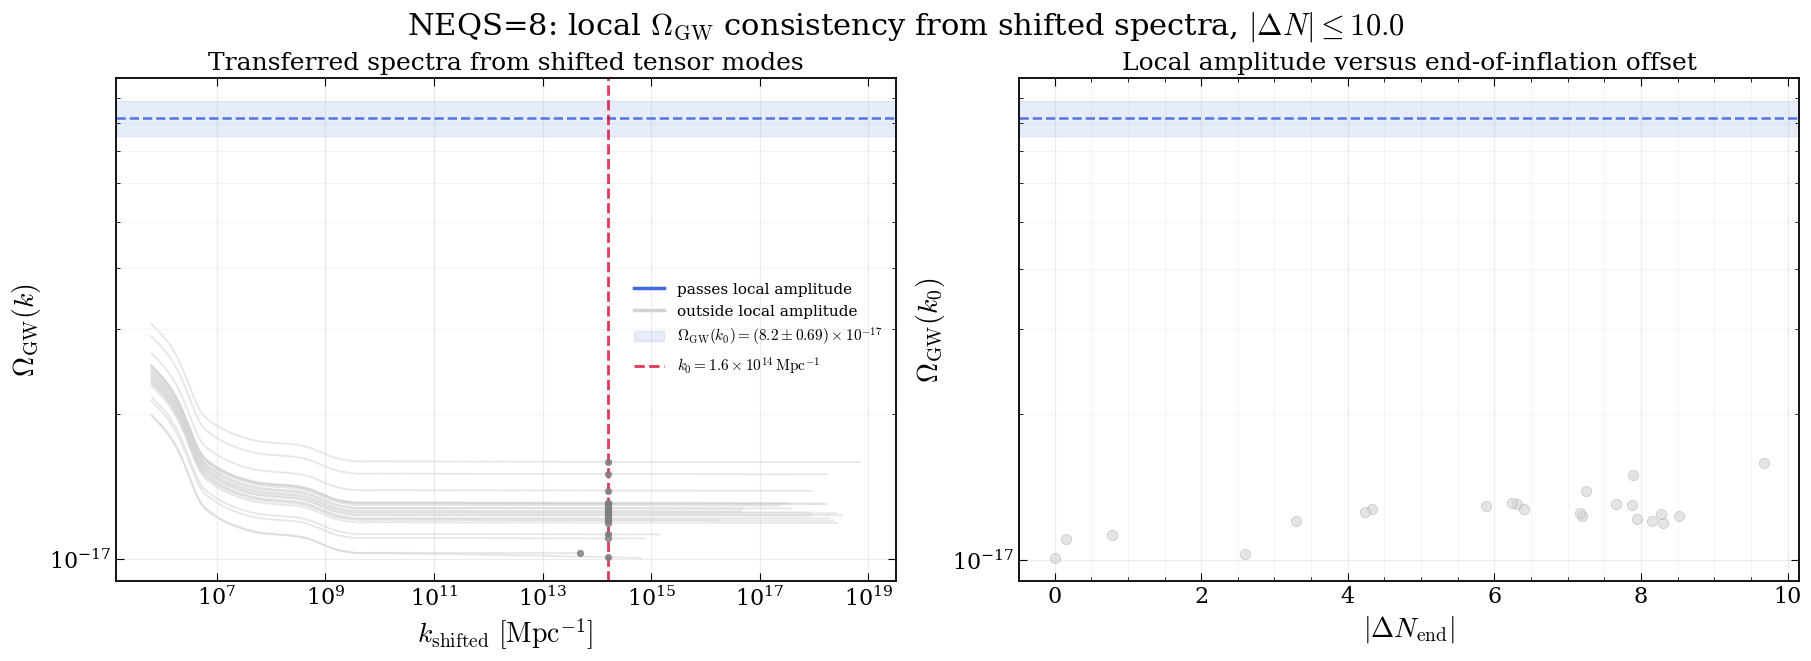


=== OmegaGW local-amplitude summary ===
Total models checked      : 30
Kept models               : 23
Pass OmegaGW(k0)          : 0
Fail OmegaGW(k0)          : 23
Rejected by |deltaN| cut  : 7
Rejected by TF overlap    : 0
Rejected other            : 0

Passing models:
Empty DataFrame
Columns: [lam5, deltaN_from_base, OmegaGW_at_k0, k_nearest_k0]
Index: []


In [29]:
omega8_pass_df = plot_shifted_omegaGW_pass_fail(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    h=0.67,
    k0=1.6e14,
    omega_target=8.2e-17,
    omega_tol=0.69e-17,
    max_abs_deltaN=10.0,
    save_name="neqs8_lam5_omegaGW_pass_fail_dN10.png",
)

## Let's scan the range we get for the tensor indices given the models we have!

In [30]:
def plot_shifted_nT_distribution(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_target_mpc=1.6e14,
    h=0.67,
    max_abs_deltaN=None,
    bins=12,
    smoothing=0.0,
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    k_target_hmpc = k_target_mpc / h

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"

        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_tensor_spectrum(value):

        folder = folder_for(value)

        t = np.loadtxt(
            os.path.join(folder, f"spec_t_neqs{NEQS}.dat")
        )

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_t, Pt

    def get_original_N_end(value):

        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}"
            )

        return float(
            matches.iloc[0]["original_N_end"]
        )

    def compute_shifted_nT(
        k_shifted,
        Pt,
    ):

        mask = (
            np.isfinite(k_shifted)
            & np.isfinite(Pt)
            & (k_shifted > 0)
            & (Pt > 0)
        )

        k_use = k_shifted[mask]
        Pt_use = Pt[mask]

        if len(k_use) < 5:
            return np.nan

        ln_k = np.log(k_use)
        ln_Pt = np.log(Pt_use)

        ln_k_unique = np.unique(ln_k)

        ln_Pt_unique = np.array([
            np.mean(
                ln_Pt[ln_k == x]
            )
            for x in ln_k_unique
        ])

        if not (
            ln_k_unique.min()
            <= np.log(k_target_hmpc)
            <= ln_k_unique.max()
        ):
            return np.nan

        spline = UnivariateSpline(
            ln_k_unique,
            ln_Pt_unique,
            s=smoothing,
            k=3,
        )

        return float(
            spline.derivative(1)(
                np.log(k_target_hmpc)
            )
        )

    base_N_end = get_original_N_end(baseX)

    rows = []

    lam_vals = sanitize_lam_values(
        lamX_values
    )

    for value in lam_vals:

        try:

            model_N_end = get_original_N_end(
                value
            )

            deltaN = (
                model_N_end
                - base_N_end
            )

            if (
                max_abs_deltaN is not None
                and np.abs(deltaN)
                > max_abs_deltaN
            ):
                continue

            k_t, Pt = load_tensor_spectrum(
                value
            )

            # same shift used in OmegaGW analysis
            k_shifted = (
                k_t
                * np.exp(-deltaN)
            )

            nT = compute_shifted_nT(
                k_shifted,
                Pt,
            )

            rows.append({
                scan_name: value,
                "deltaN": deltaN,
                "abs_deltaN": np.abs(deltaN),
                "nT": nT,
            })

        except Exception as e:

            print(
                f"Skipping "
                f"{scan_name}={value:.5e}: "
                f"{e}"
            )

    nT_df = pd.DataFrame(rows)

    finite = (
        nT_df["nT"]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .values
    )

    fig, ax = plt.subplots(
        figsize=(10.5, 6.5),
        constrained_layout=True,
    )

    ax.hist(
        finite,
        bins=bins,
        color="mediumslateblue",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.82,
    )

    ax.axvline(
        0,
        color="black",
        ls="--",
        lw=1.5,
        alpha=0.7,
        label=r"$n_T=0$",
    )

    if len(finite) > 0:

        median_nT = np.nanmedian(
            finite
        )

        ax.axvline(
            median_nT,
            color="crimson",
            lw=2,
            alpha=0.9,
            label=rf"median={median_nT:.3e}",
        )

    ax.set_xlabel(
        r"$n_T(k_0)$"
    )

    ax.set_ylabel(
        r"Number of models"
    )

    title = (
        rf"Tensor tilt distribution "
        rf"at "
        rf"$k_0={k_target_mpc:.1e}\,"
        rf"{{\rm Mpc}}^{{-1}}$"
    )

    if max_abs_deltaN is not None:

        title += (
            rf", "
            rf"$|\Delta N|"
            rf"\leq{max_abs_deltaN}$"
        )

    ax.set_title(title)

    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )

    ax.grid(
        True,
        which="minor",
        alpha=0.12,
    )

    ax.minorticks_on()

    ax.legend(
        frameon=False,
        loc="best",
    )

    if save_name is None:

        save_name = (
            f"neqs{NEQS}_"
            f"shifted_nT_distribution.png"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    print("\n=== Shifted nT summary ===")

    if len(finite) > 0:

        print(
            f"min nT    = "
            f"{np.nanmin(finite):.6e}"
        )

        print(
            f"median nT = "
            f"{np.nanmedian(finite):.6e}"
        )

        print(
            f"max nT    = "
            f"{np.nanmax(finite):.6e}"
        )

    return nT_df

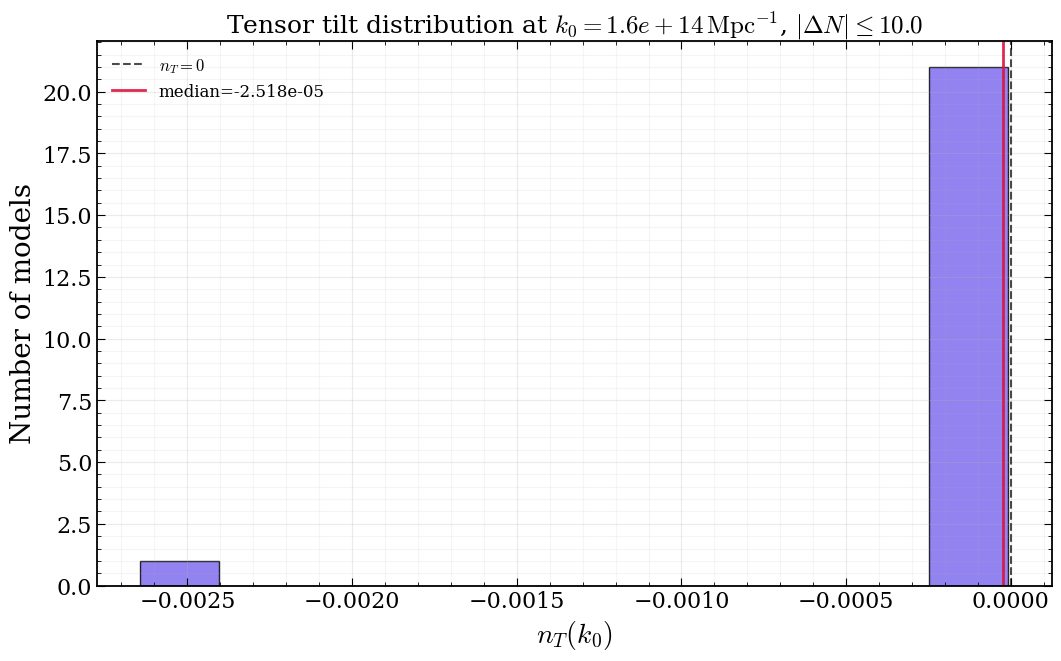


=== Shifted nT summary ===
min nT    = -2.642876e-03
median nT = -2.518166e-05
max nT    = -7.831215e-06


In [31]:
nT_df = plot_shifted_nT_distribution(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    k_target_mpc=1.6e14,
    h=0.67,
    max_abs_deltaN=10.0,
    bins=11,
    save_name="neqs8_shifted_nT_distribution.png",
)

We can compare $\Omega_{GW}(k_0)$ and $n_T(k_0)$ to try and unpack more that relationship. Keep in mind that $n_T(k) = \frac{d ln P_t}{d ln k}$ and roughly speaking $\Omega_{GW} \propto T(k)P_t(k)$. It is $n_T(k)$ that controls the slope of $P_t$ but $\Omega_{GW}$ depends on the amplitude of $P_t$ more directly.

In [36]:
def plot_omegaGW_vs_nT_at_k0(
    omega_df,
    nT_df,
    omega_target=8.2e-17,
    omega_tol=0.69e-17,
    k0=1.6e14,
    color_by="abs_deltaN_from_base",
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    df_omega = omega_df.copy()
    df_nt = nT_df.copy()

    # Try to merge on the scan parameter automatically.
    common_cols = [
        c for c in df_omega.columns
        if c in df_nt.columns
        and c not in [
            "n_T", "nT", "OmegaGW_at_k0", "OmegaGW_h2_at_k0",
            "deltaN", "abs_deltaN"
        ]
    ]

    # Prefer the lambda scan parameter if present.
    scan_cols = [
        c for c in common_cols
        if c.startswith("lam")
    ]

    if len(scan_cols) > 0:
        merge_col = scan_cols[0]
        df = pd.merge(df_omega, df_nt, on=merge_col, how="inner")
    elif "model_index" in df_omega.columns and "model_index" in df_nt.columns:
        merge_col = "model_index"
        df = pd.merge(df_omega, df_nt, on="model_index", how="inner")
    else:
        raise ValueError(
            "Could not automatically merge omega_df and nT_df. "
            "Make sure both contain the same lambda column, e.g. lam5, or model_index."
        )

    # Standardize nT column name.
    if "nT" in df.columns:
        nt_col = "nT"
    elif "n_T" in df.columns:
        nt_col = "n_T"
    else:
        raise ValueError("Could not find nT column. Expected 'nT' or 'n_T'.")

    if "OmegaGW_at_k0" not in df.columns:
        raise ValueError("omega_df must contain 'OmegaGW_at_k0'.")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[nt_col, "OmegaGW_at_k0"])

    df["passes_omega"] = (
        np.abs(df["OmegaGW_at_k0"] - omega_target) <= omega_tol
    )

    fig, ax = plt.subplots(
        figsize=(10.5, 7.0),
        constrained_layout=True,
    )

    # Target band
    ax.axhspan(
        omega_target - omega_tol,
        omega_target + omega_tol,
        color="royalblue",
        alpha=0.12,
        label=rf"$\Omega_{{\rm GW}}(k_0)=(8.2\pm0.69)\times10^{{-17}}$",
    )

    ax.axhline(
        omega_target,
        color="royalblue",
        ls="--",
        lw=2.0,
        alpha=0.9,
    )

    # Color choice
    if color_by is not None and color_by in df.columns:
        sc = ax.scatter(
            df[nt_col],
            df["OmegaGW_at_k0"],
            c=df[color_by],
            cmap="plasma",
            s=90,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
            zorder=3,
        )

        cbar = fig.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label(color_by.replace("_", r"\_"), fontsize=16)
        cbar.ax.tick_params(labelsize=13, direction="in")

    else:
        ax.scatter(
            df[nt_col],
            df["OmegaGW_at_k0"],
            color="mediumslateblue",
            s=90,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
            zorder=3,
        )

    # Highlight passers, if any.
    pass_df = df[df["passes_omega"]]

    if len(pass_df) > 0:
        ax.scatter(
            pass_df[nt_col],
            pass_df["OmegaGW_at_k0"],
            s=180,
            marker="*",
            color="royalblue",
            edgecolor="black",
            linewidth=0.8,
            zorder=5,
            label=f"passes local amplitude ({len(pass_df)})",
        )

    ax.set_yscale("log")

    ax.set_xlabel(r"$n_T(k_0)=d\ln P_t/d\ln k$")
    ax.set_ylabel(r"$\Omega_{\rm GW}(k_0)$")

    ax.set_title(
        rf"Local gravitational-wave amplitude versus tensor tilt at "
        rf"$k_0={k0:.1e}\,{{\rm Mpc}}^{{-1}}$"
    )

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()
    ax.legend(frameon=False, loc="best")

    if save_name is None:
        save_name = "omegaGW_vs_nT_at_k0.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    print("\n=== OmegaGW vs nT summary ===")
    print(f"Merged on: {merge_col}")
    print(f"Models plotted: {len(df)}")
    print(f"Passing OmegaGW target: {df['passes_omega'].sum()}")

    if len(df) > 1:
        corr = df[[nt_col, "OmegaGW_at_k0"]].corr().iloc[0, 1]
        print(f"Linear correlation nT vs OmegaGW_at_k0: {corr:.4f}")

    return df

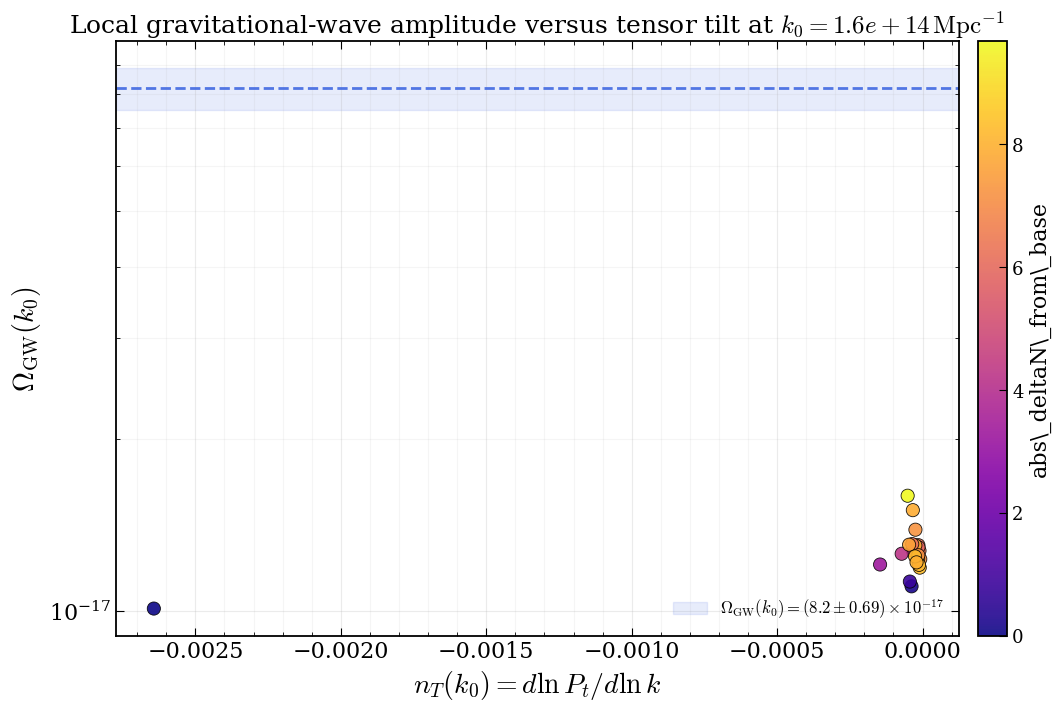


=== OmegaGW vs nT summary ===
Merged on: lam5
Models plotted: 22
Passing OmegaGW target: 0
Linear correlation nT vs OmegaGW_at_k0: 0.4663


In [37]:
omega_nT_df = plot_omegaGW_vs_nT_at_k0(
    omega_df=omega8_pass_df,
    nT_df=nT_df,
    omega_target=8.2e-17,
    omega_tol=0.69e-17,
    k0=1.6e14,
    color_by="abs_deltaN_from_base",
    save_name="neqs8_omegaGW_vs_nT_k0.png",
)

## Multi-Scale Models

We want to coordinate this next function so that of the $\Omega_{GW}$ amplitude we expect for space detectors, we can further specify the amplitude or whatever expected at nanograv scales or something.

In [44]:
def plot_multiscale_omegaGW_selection(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    h=0.67,

    # Space detector / DECIGO-like scale
    k_space=1.6e14,
    omega_space_target=8.2e-17,
    omega_space_tol=0.69e-17,

    # PTA / NANOGrav-like band
    f_pta_min=1e-9,
    f_pta_max=1e-7,
    omega_pta_min=None,
    omega_pta_max=None,

    max_abs_deltaN=None,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    c_light = 299792458.0
    m_per_Mpc = 3.085677581e22

    k_pta_min = 2.0 * np.pi * f_pta_min / c_light * m_per_Mpc
    k_pta_max = 2.0 * np.pi * f_pta_max / c_light * m_per_Mpc

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))
        return k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[scan_name], value)]

        if len(matches) == 0:
            raise ValueError(f"No summary row found for {scan_name}={value:.10e}")

        return float(matches.iloc[0]["original_N_end"])

    # Transfer function interpolation
    tf_k = np.asarray(tf_k_invMpc)
    tf_T = np.asarray(tf_median)

    good_tf = (
        np.isfinite(tf_k)
        & np.isfinite(tf_T)
        & (tf_k > 0)
        & (tf_T > 0)
    )

    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    order_tf = np.argsort(tf_k)
    tf_k = tf_k[order_tf]
    tf_T = tf_T[order_tf]

    logT_spline = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    kmin_tf = tf_k.min()
    kmax_tf = tf_k.max()

    lam_vals = sanitize_lam_values(lamX_values)
    base_N_end = get_original_N_end(baseX)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.8),
        constrained_layout=True,
    )

    ax_curves, ax_scatter = axes

    rows = []

    pta_cut_is_defined = (
        omega_pta_min is not None
        or omega_pta_max is not None
    )

    for value in lam_vals:
        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end
            abs_deltaN = np.abs(deltaN)

            if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                continue

            k_t_raw, Pt_raw = load_specs_local(value)

            k_shifted = k_t_raw * np.exp(-deltaN)

            mask = (
                np.isfinite(k_shifted)
                & np.isfinite(Pt_raw)
                & (k_shifted > 0)
                & (Pt_raw > 0)
                & (k_shifted >= kmin_tf)
                & (k_shifted <= kmax_tf)
            )

            if np.count_nonzero(mask) < 5:
                continue

            k_use = k_shifted[mask]
            Pt_use = Pt_raw[mask]

            T_use = np.exp(logT_spline(np.log(k_use)))

            valid = np.isfinite(T_use) & (T_use > 0)
            k_use = k_use[valid]
            Pt_use = Pt_use[valid]
            T_use = T_use[valid]

            if len(k_use) < 5:
                continue

            OmegaGW_h2 = T_use * Pt_use
            OmegaGW = OmegaGW_h2 / h**2

            # Space detector point
            j_space = np.argmin(np.abs(k_use - k_space))
            omega_space = OmegaGW[j_space]
            k_space_nearest = k_use[j_space]

            passes_space = (
                np.abs(omega_space - omega_space_target)
                <= omega_space_tol
            )

            # PTA band
            pta_mask = (k_use >= k_pta_min) & (k_use <= k_pta_max)

            if np.count_nonzero(pta_mask) > 0:
                omega_pta_max_model = np.nanmax(OmegaGW[pta_mask])
                omega_pta_mean_model = np.nanmean(OmegaGW[pta_mask])
            else:
                omega_pta_max_model = np.nan
                omega_pta_mean_model = np.nan

            if pta_cut_is_defined:
                passes_pta = True

                if omega_pta_min is not None:
                    passes_pta &= omega_pta_max_model >= omega_pta_min

                if omega_pta_max is not None:
                    passes_pta &= omega_pta_max_model <= omega_pta_max
            else:
                passes_pta = False

            passes_both = passes_space and passes_pta

            if pta_cut_is_defined and passes_both:
                color = "royalblue"
                lw = 2.6
                alpha = 0.95
                zorder = 5
            elif passes_space:
                color = "violet"
                lw = 2.0
                alpha = 0.85
                zorder = 4
            else:
                color = "lightgray"
                lw = 1.2
                alpha = 0.50
                zorder = 1

            ax_curves.loglog(
                k_use,
                OmegaGW,
                color=color,
                lw=lw,
                alpha=alpha,
                zorder=zorder,
            )

            ax_scatter.scatter(
                omega_space,
                omega_pta_max_model,
                color=color,
                edgecolor="black" if passes_space else "gray",
                linewidth=0.6,
                s=95 if passes_space else 55,
                alpha=0.95 if passes_space else 0.55,
                zorder=zorder,
            )

            rows.append({
                scan_name: value,
                "deltaN_from_base": deltaN,
                "abs_deltaN_from_base": abs_deltaN,

                "k_space_requested": k_space,
                "k_space_nearest": k_space_nearest,
                "OmegaGW_space": omega_space,
                "passes_space": passes_space,

                "f_pta_min": f_pta_min,
                "f_pta_max": f_pta_max,
                "k_pta_min": k_pta_min,
                "k_pta_max": k_pta_max,
                "OmegaGW_pta_max": omega_pta_max_model,
                "OmegaGW_pta_mean": omega_pta_mean_model,
                "pta_cut_defined": pta_cut_is_defined,
                "passes_pta": passes_pta,

                "passes_space_and_pta": passes_both,
            })

        except Exception as e:
            print(f"Skipping {scan_name}={value:.5e}: {e}")

    df = pd.DataFrame(rows)

    omega_space_low = omega_space_target - omega_space_tol
    omega_space_high = omega_space_target + omega_space_tol

    # Left panel guide bands
    ax_curves.axvline(
        k_space,
        color="crimson",
        ls="--",
        lw=2.0,
        alpha=0.85,
        label=rf"space scale $k_0={k_space:.1e}$",
    )

    ax_curves.axhspan(
        omega_space_low,
        omega_space_high,
        color="violet",
        alpha=0.12,
        label="space-detector target band",
    )

    ax_curves.axvspan(
        k_pta_min,
        k_pta_max,
        color="royalblue",
        alpha=0.10,
        label="PTA band",
    )

    # Right panel guide bands
    ax_scatter.axvspan(
        omega_space_low,
        omega_space_high,
        color="violet",
        alpha=0.12,
    )

    if omega_pta_min is not None:
        ax_scatter.axhline(
            omega_pta_min,
            color="royalblue",
            ls="--",
            lw=1.8,
            alpha=0.85,
            label="PTA lower target",
        )

    if omega_pta_max is not None:
        ax_scatter.axhline(
            omega_pta_max,
            color="royalblue",
            ls=":",
            lw=1.8,
            alpha=0.85,
            label="PTA upper target",
        )

    fail_handle = plt.Line2D(
        [0], [0],
        color="lightgray",
        lw=2.5,
        label="outside space target",
    )

    pass_space_handle = plt.Line2D(
        [0], [0],
        color="violet",
        lw=2.5,
        label="passes space scale",
    )

    legend_handles = [
        fail_handle,
        pass_space_handle,
    ]

    if pta_cut_is_defined:
        pass_both_handle = plt.Line2D(
            [0], [0],
            color="royalblue",
            lw=2.5,
            label="passes space + PTA",
        )

        legend_handles.append(pass_both_handle)

    legend_handles.extend(
        ax_curves.get_legend_handles_labels()[0]
    )

    ax_curves.legend(
        handles=legend_handles,
        frameon=False,
        loc="best",
        fontsize=10,
    )

    # No scatter legend needed unless PTA cut lines exist.
    scatter_handles, scatter_labels = ax_scatter.get_legend_handles_labels()
    if len(scatter_handles) > 0:
        ax_scatter.legend(
            frameon=False,
            loc="best",
            fontsize=10,
        )

    ax_curves.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    ax_curves.set_ylabel(r"$\Omega_{\rm GW}(k)$")
    ax_curves.set_title(r"Multi-scale gravitational-wave spectra")

    ax_scatter.set_xscale("log")
    ax_scatter.set_yscale("log")
    ax_scatter.set_xlabel(r"$\Omega_{\rm GW}(k_{\rm space})$")
    ax_scatter.set_ylabel(r"$\max_{\rm PTA}\,\Omega_{\rm GW}$")
    ax_scatter.set_title(r"PTA-band amplitude versus space-scale amplitude")

    for ax in axes:
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

    cut_text = ""
    if max_abs_deltaN is not None:
        cut_text = rf", $|\Delta N|\leq {max_abs_deltaN}$"

    fig.suptitle(
        rf"NEQS={NEQS}: multi-scale $\Omega_{{\rm GW}}$ selection{cut_text}",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_multiscale_omegaGW_selection.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    print("\n=== Multi-scale OmegaGW summary ===")
    print(f"Models evaluated: {len(df)}")

    if not df.empty:
        print(f"Pass space scale: {df['passes_space'].sum()}")

        if pta_cut_is_defined:
            print(f"Pass PTA band: {df['passes_pta'].sum()}")
            print(f"Pass both: {df['passes_space_and_pta'].sum()}")
        else:
            print("PTA pass/fail not applied: set omega_pta_min and/or omega_pta_max to classify.")

        print("\nPassing both:")
        if pta_cut_is_defined:
            print(
                df[df["passes_space_and_pta"]][[
                    scan_name,
                    "deltaN_from_base",
                    "OmegaGW_space",
                    "OmegaGW_pta_max",
                ]].to_string(index=False)
            )
        else:
            print("No PTA cut was defined.")

    return df

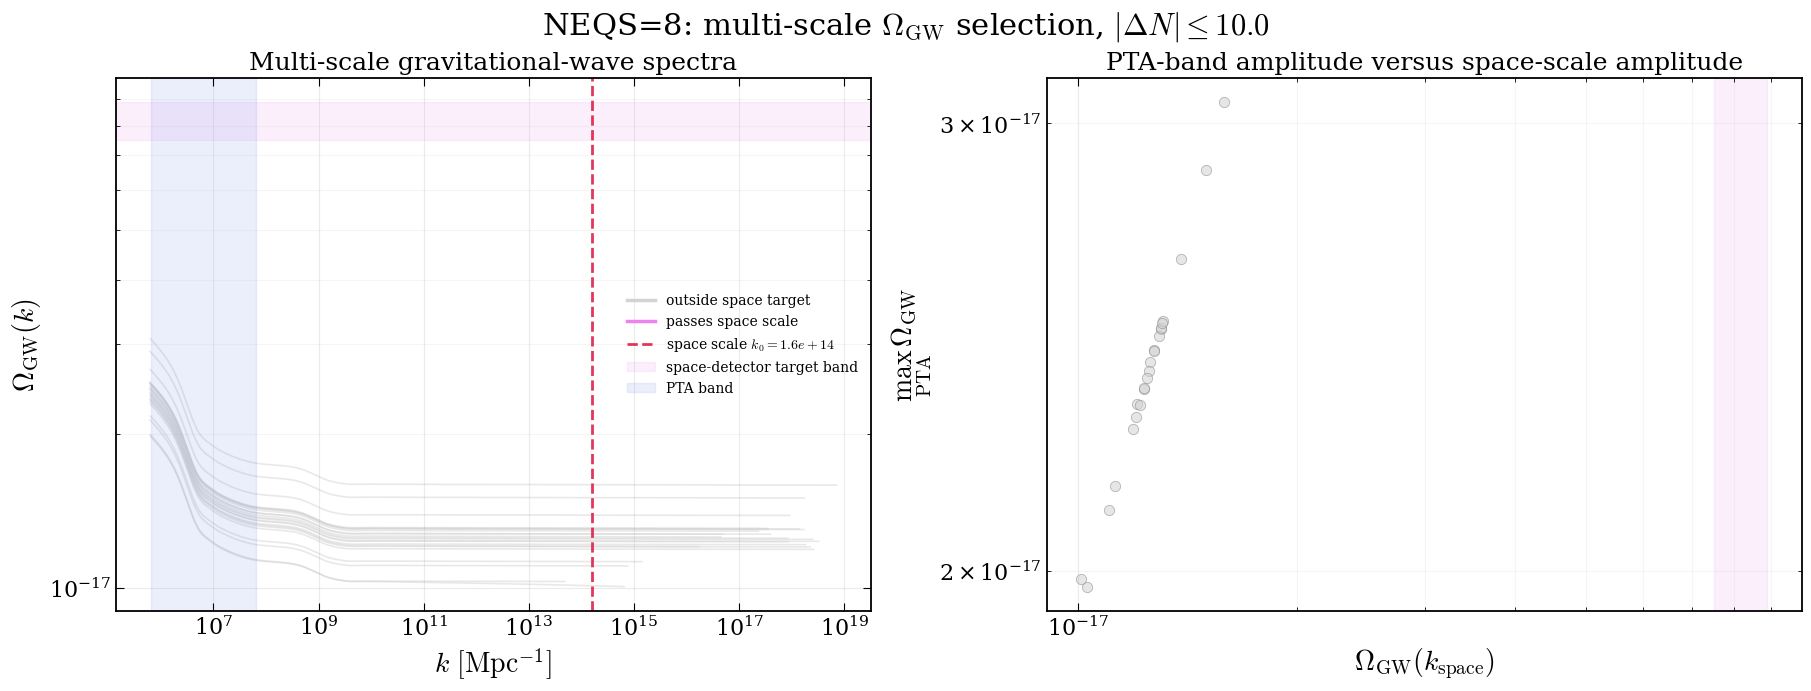


=== Multi-scale OmegaGW summary ===
Models evaluated: 23
Pass space scale: 0
PTA pass/fail not applied: set omega_pta_min and/or omega_pta_max to classify.

Passing both:
No PTA cut was defined.


In [45]:
multiscale8_df = plot_multiscale_omegaGW_selection(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    h=0.67,

    k_space=1.6e14,
    omega_space_target=8.2e-17,
    omega_space_tol=0.69e-17,

    f_pta_min=1e-9,
    f_pta_max=1e-7,

    # Fill these once you decide the NANOGrav/PTA amplitude criterion
    omega_pta_min=None,
    omega_pta_max=None,

    max_abs_deltaN=10.0,
    save_name="neqs8_multiscale_omegaGW_selection.png",
)

Notes on the above plot:

This analysis provides a multi-scale characterization of inflationary models by comparing their predicted gravitational-wave amplitudes at both interferometer and PTA scales. The resulting distribution of $\Omega_{GW}$ values identifies models that may simultaneously satisfy cosmological constraints and produce potentially observable stochastic backgrounds at multiple gravitational-wave frequencies.